In [68]:
pip install yfinance


In [69]:
import yfinance as yf

# 下载江西铜业的股票数据
ticker = "600362.SS"  # 上海交易所的股票代码后缀为 .SS
start_date = "2021-03-28"
end_date = "2025-03-28"

# 获取数据
data = yf.download(ticker, start=start_date, end=end_date)

# 保存为CSV文件
data.to_csv('recent_stock_prices.csv')
print("数据已保存到 recent_stock_prices.csv")


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed

数据已保存到 recent_stock_prices.csv


In [85]:
import pandas as pd

try:
    data = pd.read_csv('recent_stock_prices.csv')
    print("CSV 数据预览：")
    print(data.head())  # 显示前几行数据
except pd.errors.EmptyDataError:
    print("CSV 文件为空，请检查数据来源或重新下载。")
except FileNotFoundError:
    print("文件不存在，请确认文件路径是否正确。")


CSV 数据预览：
        Price               Close                High                 Low  \
0      Ticker           600362.SS           600362.SS           600362.SS   
1        Date                 NaN                 NaN                 NaN   
2  2021-03-29  20.174652099609375   20.36705257110794  19.844820722747205   
3  2021-03-30  20.641910552978516   20.78850187291259  19.441691718197013   
4  2021-03-31  20.266273498535156  20.422027020697517   19.95476645421044   

                 Open     Volume  
0           600362.SS  600362.SS  
1                 NaN        NaN  
2  20.339567788040462   37252373  
3  19.881467425505612   62773515  
4  20.330406993394952   32386023  


In [72]:
import pandas as pd

# 加载数据
data = pd.read_csv('recent_stock_prices.csv')

# 清理列名和删除无关行
data.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']  # 设置正确的列名
data = data.iloc[2:]  # 删除前两行
data.reset_index(drop=True, inplace=True)

# 转换日期格式
data['Date'] = pd.to_datetime(data['Date'])

# 检查并处理缺失值
data = data.dropna()  # 删除含有缺失值的行（也可以选择填充方式）

# 保存清洗后的数据
data.to_csv('cleaned_stock_prices.csv', index=False)
print("数据已清洗并保存到 cleaned_stock_prices.csv")
# 加载清洗后的数据
data = pd.read_csv('cleaned_stock_prices.csv')

# 打印前五行
print("清洗后数据的前五行：")
print(data.head())


数据已清洗并保存到 cleaned_stock_prices.csv
清洗后数据的前五行：
         Date      Close       High        Low       Open    Volume
0  2021-03-29  20.174652  20.367053  19.844821  20.339568  37252373
1  2021-03-30  20.641911  20.788502  19.441692  19.881467  62773515
2  2021-03-31  20.266273  20.422027  19.954766  20.330407  32386023
3  2021-04-01  20.339567  20.559454  19.899791  20.183814  32773458
4  2021-04-02  21.164143  21.246600  20.128839  20.257108  55528531


In [73]:
import os
print("当前工作目录：", os.getcwd())


当前工作目录： /content


In [84]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt

# 加载数据
data = pd.read_csv('cleaned_stock_prices.csv')
data = data[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]

# 添加技术指标
def calculate_rsi(data, window=14):
    delta = data['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

data['RSI'] = calculate_rsi(data)
data['SMA_50'] = data['Close'].rolling(window=50).mean()
data['EMA_20'] = data['Close'].ewm(span=20, adjust=False).mean()

# 填充缺失值
data.fillna(method='ffill', inplace=True)

# 数据标准化
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data.drop(columns=['Date']))
print("标准化数据的最后五行（部分列显示）：")
print(scaled_data[-5:])


# 创建数据集
def create_dataset(dataset, time_step=60):
    dataX, dataY = [], []
    for i in range(len(dataset) - time_step - 1):
        a = dataset[i:(i + time_step), :]
        dataX.append(a)
        dataY.append(dataset[i + time_step, [0, 3]])  # 同时预测开盘价（第0列）和收盘价（第3列）
    return np.array(dataX), np.array(dataY)

time_step = 60
X, y = create_dataset(scaled_data, time_step)

# 划分训练集和测试集
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# 构建模型
model = Sequential()
model.add(Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(time_step, scaled_data.shape[1])))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))
model.add(LSTM(100, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(100))
model.add(Dropout(0.2))
model.add(Dense(2))  # 输出两个值：开盘价和收盘价

# 编译模型
model.compile(optimizer='adam', loss='mean_squared_error')

# 添加回调函数
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)

# 训练模型
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=64, callbacks=[early_stopping, model_checkpoint], verbose=1)

# 加载最佳模型
model.load_weights('best_model.h5')

标准化数据的最后五行（部分列显示）：
[[0.59923526 0.5681838  0.61727818 0.54589704 0.23527833 0.71695745
  0.61518582 0.64083942]
 [0.58632953 0.63921843 0.62367991 0.6374022  0.58208052 0.81916118
  0.62103195 0.6543135 ]
 [0.6895754  0.69407689 0.72690778 0.68597039 0.67811817 0.84527952
  0.62777435 0.67254803]
 [0.76245488 0.76159487 0.78372324 0.69230538 0.84789015 0.83472368
  0.63429269 0.68983424]
 [0.67515131 0.65680125 0.71970582 0.64092171 0.42026748 0.67968067
  0.64013882 0.69908011]]
Epoch 1/50


<ipython-input-84-c6aa1e1434cc>:27: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1413

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 0.1353 - val_loss: 0.0860
Epoch 2/50
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0653

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0648 - val_loss: 0.0343
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0556 - val_loss: 0.0381
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0481 - val_loss: 0.0373
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0502 - val_loss: 0.0383
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0489 - val_loss: 0.0462
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0507 - val_loss: 0.0407
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0476

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0477 - val_loss: 0.0284
Epoch 9/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0476 - val_loss: 0.0474
Epoch 10/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0488 - val_loss: 0.0470
Epoch 11/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0459 - val_loss: 0.0289
Epoch 12/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0484 - val_loss: 0.0357
Epoch 13/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0480 - val_loss: 0.0401
Epoch 14/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0480 - val_loss: 0.0446
Epoch 15/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0438 - val_loss: 0.0325
Epoch 16/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0431 - val_loss: 0.0330
Epoch 17/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0451 - val_loss: 0.0398
Epoch 18/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0431 - val_loss: 0.0330


In [75]:
# 预测
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [76]:
# 反标准化预测结果
train_predict = scaler.inverse_transform(
    np.concatenate((train_predict, np.zeros((train_predict.shape[0], scaled_data.shape[1] - 2))), axis=1)
)[:, [0, 3]]

test_predict = scaler.inverse_transform(
    np.concatenate((test_predict, np.zeros((test_predict.shape[0], scaled_data.shape[1] - 2))), axis=1)
)[:, [0, 3]]

y_train = scaler.inverse_transform(
    np.concatenate((y_train, np.zeros((y_train.shape[0], scaled_data.shape[1] - 2))), axis=1)
)[:, [0, 3]]

y_test = scaler.inverse_transform(
    np.concatenate((y_test, np.zeros((y_test.shape[0], scaled_data.shape[1] - 2))), axis=1)
)[:, [0, 3]]


In [77]:
# 计算均方误差
train_score_open = np.sqrt(np.mean((train_predict[:, 0] - y_train[:, 0]) ** 2))  # 开盘价
train_score_close = np.sqrt(np.mean((train_predict[:, 1] - y_train[:, 1]) ** 2))  # 收盘价
test_score_open = np.sqrt(np.mean((test_predict[:, 0] - y_test[:, 0]) ** 2))  # 开盘价
test_score_close = np.sqrt(np.mean((test_predict[:, 1] - y_test[:, 1]) ** 2))  # 收盘价

print(f'Train Score (Open): {train_score_open:.2f} RMSE')
print(f'Train Score (Close): {train_score_close:.2f} RMSE')
print(f'Test Score (Open): {test_score_open:.2f} RMSE')
print(f'Test Score (Close): {test_score_close:.2f} RMSE')


Train Score (Open): 2.89 RMSE
Train Score (Close): 0.00 RMSE
Test Score (Open): 2.35 RMSE
Test Score (Close): 0.00 RMSE


In [78]:
future_predictions = []

for _ in range(30):  # 预测未来 30 天的开盘价和收盘价
    prediction = model.predict(input_data)  # 模型预测
    future_predictions.append(prediction[0])  # 存储预测值

    # 调整 prediction 的形状，匹配 input_data 的特征数
    padded_prediction = np.zeros((1, 1, input_data.shape[2]))  # 创建零填充矩阵
    padded_prediction[:, :, :2] = prediction  # 将预测值填充到前两列

    # 更新 input_data：删除第一个时间步，添加新预测值
    input_data = np.append(input_data[:, 1:, :], padded_prediction, axis=1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━

In [86]:
print("反标准化前的预测值：", future_predictions[:5])


反标准化前的预测值： [array([0.38816807, 0.3579652 ], dtype=float32), array([0.38816807, 0.3579652 ], dtype=float32), array([0.38816807, 0.3579652 ], dtype=float32), array([0.38816807, 0.3579652 ], dtype=float32), array([0.38816807, 0.3579652 ], dtype=float32)]


In [79]:
# 反标准化未来预测
future_predictions = scaler.inverse_transform(
    np.concatenate((np.array(future_predictions), np.zeros((30, scaled_data.shape[1] - 2))), axis=1)
)[:, [0, 3]]


In [87]:
print("训练时 scaler 范围：", scaler.data_min_, scaler.data_max_)


训练时 scaler 范围： [14.4066053  14.50132335 14.23611235 14.26452827  0.          5.81387656
 15.25982504 14.81369252] [2.75790510e+01 2.87197445e+01 2.67327283e+01 2.84713688e+01
 1.30100448e+08 9.72560935e+01 2.50782811e+01 2.56869112e+01]


In [80]:
print("输入数据更新内容预览：")
print(input_data[:, -1, :])  # 打印最近一次输入数据的最后一条记录


输入数据更新内容预览：
[[0.38816807 0.3579652  0.         0.         0.         0.
  0.         0.        ]]


In [88]:
# 检查预测值是否正确反标准化
print("反标准化前的预测值：", future_predictions[:5])
future_predictions_denorm = scaler.inverse_transform(
    np.concatenate((np.array(future_predictions), np.zeros((len(future_predictions), scaled_data.shape[1] - 2))), axis=1)
)[:, [0, 3]]
print("反标准化后的预测值：", future_predictions_denorm[:5])


反标准化前的预测值： [array([0.38816807, 0.3579652 ], dtype=float32), array([0.38816807, 0.3579652 ], dtype=float32), array([0.38816807, 0.3579652 ], dtype=float32), array([0.38816807, 0.3579652 ], dtype=float32), array([0.38816807, 0.3579652 ], dtype=float32)]
反标准化后的预测值： [[19.51972807 14.26452827]
 [19.51972807 14.26452827]
 [19.51972807 14.26452827]
 [19.51972807 14.26452827]
 [19.51972807 14.26452827]]


In [81]:
future_predictions = []

for _ in range(30):  # 预测未来30天的开盘价和收盘价
    prediction = model.predict(input_data)  # 模型预测
    future_predictions.append(prediction[0])  # 存储预测值

    # 保留历史特征，并仅更新开盘价和收盘价
    padded_prediction = input_data[:, -1, :].copy()  # 复制上一时间步的特征
    padded_prediction[0, 0] = prediction[0, 0]  # 更新开盘价
    padded_prediction[0, 3] = prediction[0, 1]  # 更新收盘价
    padded_prediction = padded_prediction.reshape(1, 1, -1)

    # 将更新后的数据拼接回输入数据
    input_data = np.append(input_data[:, 1:, :], padded_prediction, axis=1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━

In [82]:
print("未来30天预测的开盘价和收盘价：")
for i, prediction in enumerate(future_predictions):
    print(f"第{i + 1}天 - 开盘价: {prediction[0]:.2f}, 收盘价: {prediction[1]:.2f}")


未来30天预测的开盘价和收盘价：
第1天 - 开盘价: 0.39, 收盘价: 0.36
第2天 - 开盘价: 0.39, 收盘价: 0.36
第3天 - 开盘价: 0.39, 收盘价: 0.36
第4天 - 开盘价: 0.39, 收盘价: 0.36
第5天 - 开盘价: 0.39, 收盘价: 0.36
第6天 - 开盘价: 0.39, 收盘价: 0.36
第7天 - 开盘价: 0.39, 收盘价: 0.36
第8天 - 开盘价: 0.39, 收盘价: 0.36
第9天 - 开盘价: 0.39, 收盘价: 0.36
第10天 - 开盘价: 0.39, 收盘价: 0.36
第11天 - 开盘价: 0.39, 收盘价: 0.36
第12天 - 开盘价: 0.39, 收盘价: 0.36
第13天 - 开盘价: 0.39, 收盘价: 0.36
第14天 - 开盘价: 0.39, 收盘价: 0.36
第15天 - 开盘价: 0.39, 收盘价: 0.36
第16天 - 开盘价: 0.39, 收盘价: 0.36
第17天 - 开盘价: 0.39, 收盘价: 0.36
第18天 - 开盘价: 0.39, 收盘价: 0.36
第19天 - 开盘价: 0.39, 收盘价: 0.36
第20天 - 开盘价: 0.39, 收盘价: 0.36
第21天 - 开盘价: 0.39, 收盘价: 0.36
第22天 - 开盘价: 0.39, 收盘价: 0.36
第23天 - 开盘价: 0.39, 收盘价: 0.36
第24天 - 开盘价: 0.39, 收盘价: 0.36
第25天 - 开盘价: 0.39, 收盘价: 0.36
第26天 - 开盘价: 0.39, 收盘价: 0.36
第27天 - 开盘价: 0.39, 收盘价: 0.36
第28天 - 开盘价: 0.39, 收盘价: 0.36
第29天 - 开盘价: 0.39, 收盘价: 0.36
第30天 - 开盘价: 0.39, 收盘价: 0.36


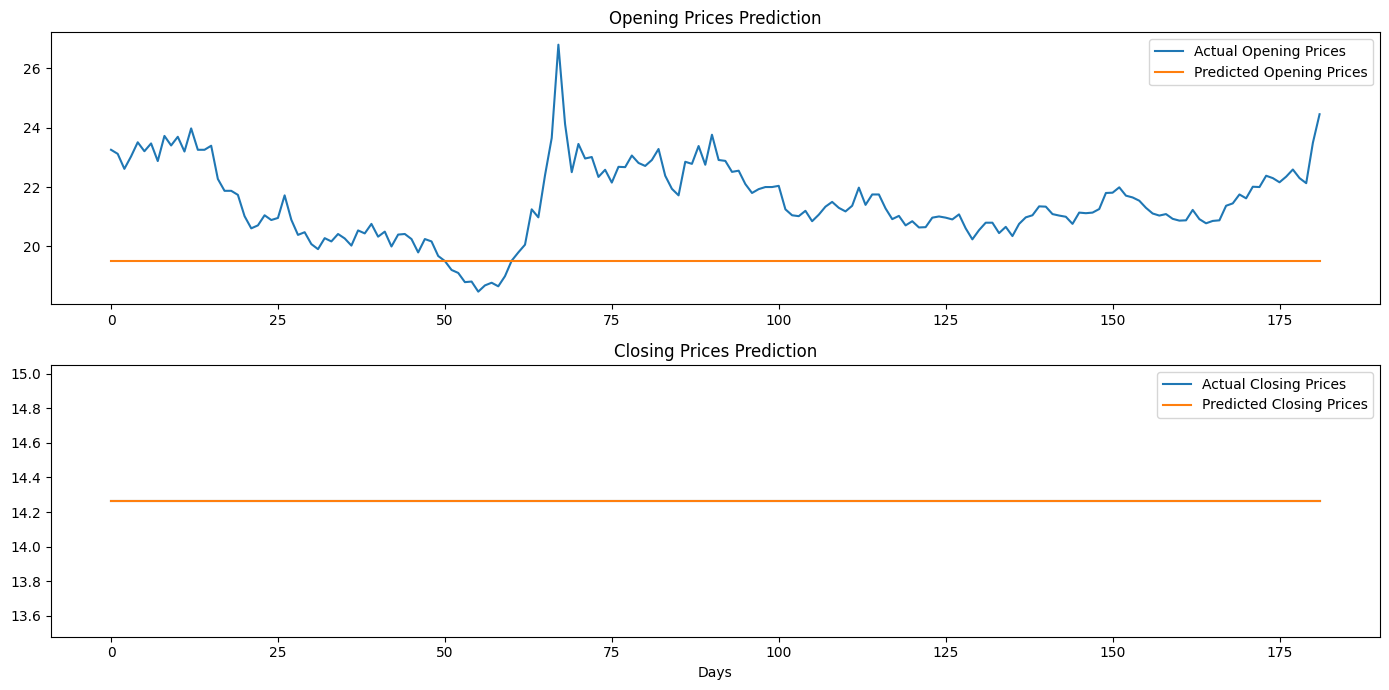

In [83]:
# 可视化结果
plt.figure(figsize=(14, 7))

# 开盘价
plt.subplot(2, 1, 1)
plt.plot(y_test[:, 0], label='Actual Opening Prices')
plt.plot(test_predict[:, 0], label='Predicted Opening Prices')
plt.title('Opening Prices Prediction')
plt.legend()

# 收盘价
plt.subplot(2, 1, 2)
plt.plot(y_test[:, 1], label='Actual Closing Prices')
plt.plot(test_predict[:, 1], label='Predicted Closing Prices')
plt.title('Closing Prices Prediction')
plt.legend()

plt.xlabel('Days')
plt.tight_layout()
plt.show()
